# Matrix Factorization Comparison

Compare ALS (implicit) vs FunkSVD (explicit) on MovieLens 1M.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.als import ALS
from src.models.funksvd import FunkSVD
from src.evaluation.metrics import compute_rmse, compute_ranking_metrics

## 1. Load and Split Data

In [2]:
ratings = load_ratings()

train_df, val_df, test_df = split_temporal(
    ratings, 
    train_ratio=0.7, 
    validation_ratio=0.15, 
    test_ratio=0.15,
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Test set: only positive interactions for ranking eval
test_positive = test_df[test_df['rating'] >= 4]
test_users = test_positive['user_id'].unique()
print(f"Test users with positive ratings: {len(test_users):,}")

Train: 700,118 | Val: 150,081 | Test: 150,010
Test users with positive ratings: 5,914


## 2. Load Models from Artifacts

In [3]:
artifacts_dir = Path('../artifacts')

# Load trained models from artifacts
with open(artifacts_dir / 'als_best.pkl', 'rb') as f:
    als_model = pickle.load(f)
print(f"Loaded ALS model: {als_model.name}")

with open(artifacts_dir / 'funksvd_best.pkl', 'rb') as f:
    funksvd_model = pickle.load(f)
print(f"Loaded FunkSVD model: {funksvd_model.name}")

Loaded FunkSVD model: FunkSVD-k10-lr0.01


## 3. Evaluate on Test Set

In [4]:
models = {
    'ALS (Implicit)': als_model,
    'FunkSVD (Explicit)': funksvd_model,
}

results = []

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Ranking metrics (on positive test interactions)
    recs = model.recommend_for_eval(test_users, k=10)
    ranking = compute_ranking_metrics(test_positive, recs, top_k=10)
    
    # RMSE (only for FunkSVD - predicts actual ratings)
    if 'FunkSVD' in name:
        preds = model.predict(test_df)
        rmse = compute_rmse(test_df, preds)
    else:
        rmse = None  # ALS doesn't predict ratings
    
    results.append({
        'Model': name,
        'NDCG@10': ranking['ndcg'],
        'Precision@10': ranking['precision'],
        'Recall@10': ranking['recall'],
        'MAP@10': ranking['map'],
        'RMSE': rmse,
    })

results_df = pd.DataFrame(results)
results_df

,Model,NDCG@10,Precision@10,Recall@10,MAP@10,RMSE
0,ALS (Implicit),0.084432,0.066520,0.070117,0.039812,NaN
1,FunkSVD (Explicit),0.040358,0.033801,0.024718,0.018406,0.885869


## 4. Visualize Comparison

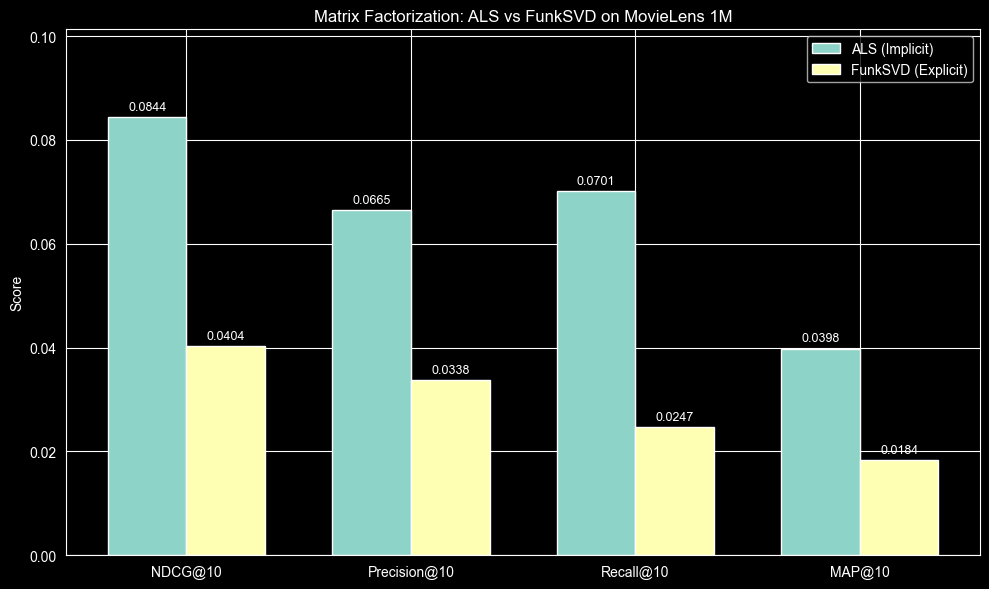

In [5]:
# Bar chart comparison of ranking metrics
metrics = ['NDCG@10', 'Precision@10', 'Recall@10', 'MAP@10']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

als_vals = results_df[results_df['Model'].str.contains('ALS')][metrics].values[0]
funk_vals = results_df[results_df['Model'].str.contains('FunkSVD')][metrics].values[0]

bars1 = ax.bar(x - width/2, als_vals, width, label='ALS (Implicit)')
bars2 = ax.bar(x + width/2, funk_vals, width, label='FunkSVD (Explicit)')

ax.set_ylabel('Score')
ax.set_title('Matrix Factorization: ALS vs FunkSVD on MovieLens 1M')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, max(max(als_vals), max(funk_vals)) * 1.2)

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../artifacts/mf_comparison.png', dpi=150)
plt.show()

## 5. Metrics vs K

In [6]:
# Evaluate at different k values
k_values = [1, 3, 5, 10, 20]
k_results = []

for name, model in models.items():
    for k in k_values:
        recs = model.recommend_for_eval(test_users, k=k)
        ranking = compute_ranking_metrics(test_positive, recs, top_k=k)
        k_results.append({
            'Model': name,
            'k': k,
            'NDCG': ranking['ndcg'],
            'Recall': ranking['recall'],
            'Precision': ranking['precision'],
        })

k_df = pd.DataFrame(k_results)
k_df

,Model,k,NDCG,Recall,Precision
0,ALS (Implicit),1,0.080994,0.009349,0.080994
1,ALS (Implicit),3,0.077707,0.025589,0.075302
2,ALS (Implicit),5,0.078720,0.039016,0.072675
3,ALS (Implicit),10,0.084432,0.070117,0.066520
4,ALS (Implicit),20,0.098578,0.119772,0.059672
5,FunkSVD (Explicit),1,0.045654,0.003540,0.045654
6,FunkSVD (Explicit),3,0.043214,0.009452,0.042329
7,FunkSVD (Explicit),5,0.042075,0.014567,0.039770
8,FunkSVD (Explicit),10,0.040358,0.024718,0.033801
9,FunkSVD (Explicit),20,0.042453,0.041640,0.028771


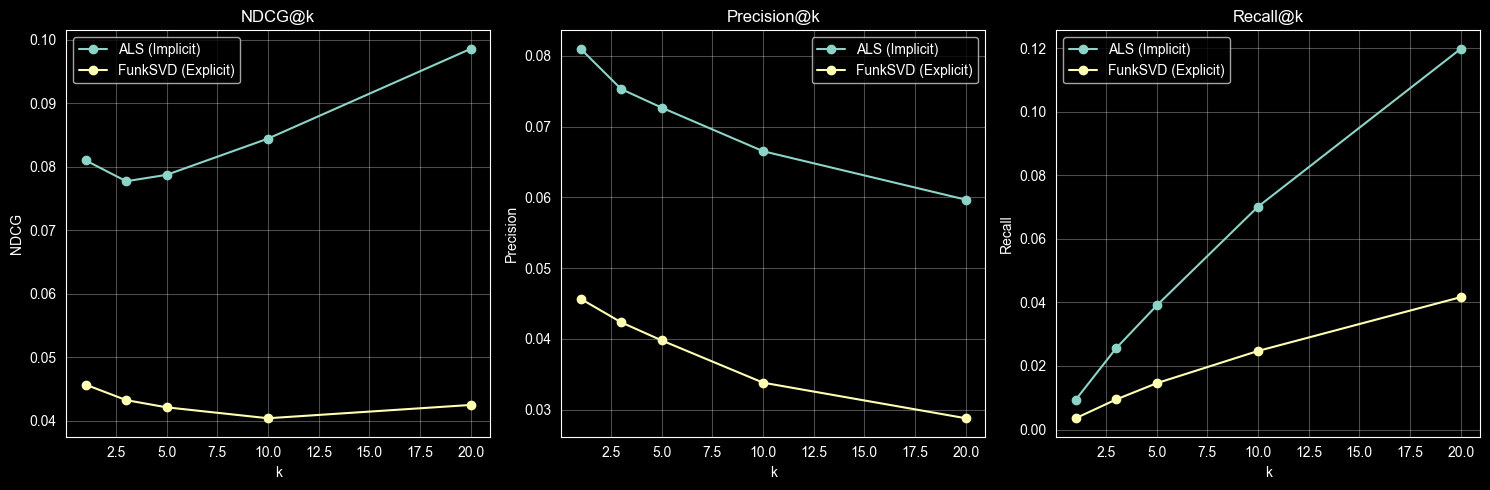

In [7]:
# Plot metrics vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['NDCG', 'Precision', 'Recall']):
    for model_name in k_df['Model'].unique():
        data = k_df[k_df['Model'] == model_name]
        ax.plot(data['k'], data[metric], marker='o', label=model_name)
    ax.set_xlabel('k')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}@k')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/mf_metrics_vs_k.png', dpi=150)
plt.show()

ALS beats FunkSVD at every k value by roughly 2x. Precision drops as k grows (more recommendations = harder to stay precise), while recall increases (more chances to hit relevant items). NDCG accounts for ranking position, so it stays more stable - a model that ranks well at k=5 will usually rank well at k=20 too.

## 5.1 Convergence Analysis

ALS uses closed-form solutions at each step, so it's guaranteed to converge. FunkSVD uses SGD which can get stuck in local minima and is sensitive to learning rate. Let's see how they behave with different iteration counts.

In [8]:
# Train both models at different iteration counts to compare convergence
from src.data.adapter import DataAdapter

adapter = DataAdapter()
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
explicit_data = adapter.to_interactions(train_val_df)
implicit_data = adapter.to_implicit(train_val_df, threshold=4.0)

iteration_counts = [1, 3, 5, 10, 20, 30]
convergence_results = []

for n_iter in iteration_counts:
    # ALS
    als = ALS(factors=10, iterations=n_iter, regularization=0.1, implicit=True, random_state=42)
    als.fit(implicit_data)
    als_recs = als.recommend_for_eval(test_users, k=10)
    als_ndcg = compute_ranking_metrics(test_positive, als_recs, top_k=10)['ndcg']
    
    # FunkSVD
    funk = FunkSVD(n_factors=10, n_epochs=n_iter, lr_all=0.01, reg_all=0.01, random_state=42)
    funk.fit(explicit_data)
    funk_recs = funk.recommend_for_eval(test_users, k=10)
    funk_ndcg = compute_ranking_metrics(test_positive, funk_recs, top_k=10)['ndcg']
    
    convergence_results.append({'iterations': n_iter, 'ALS': als_ndcg, 'FunkSVD': funk_ndcg})
    print(f"Iter {n_iter:2d}: ALS={als_ndcg:.4f}, FunkSVD={funk_ndcg:.4f}")

conv_df = pd.DataFrame(convergence_results)

Iter 30: ALS=0.0844, FunkSVD=0.0341


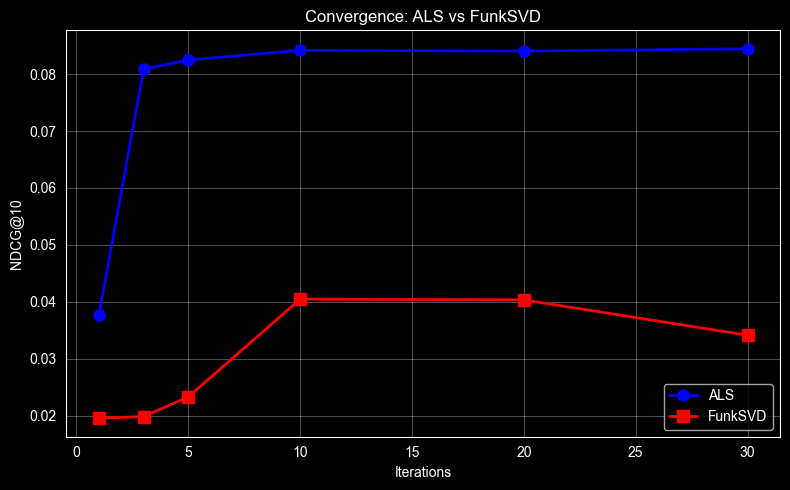

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(conv_df['iterations'], conv_df['ALS'], 'b-o', label='ALS', linewidth=2, markersize=8)
ax.plot(conv_df['iterations'], conv_df['FunkSVD'], 'r-s', label='FunkSVD', linewidth=2, markersize=8)
ax.set_xlabel('Iterations')
ax.set_ylabel('NDCG@10')
ax.set_title('Convergence: ALS vs FunkSVD')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/mf_convergence.png', dpi=150)
plt.show()

ALS converges quickly and stays stable - the closed-form solution with regularization keeps it from overfitting. FunkSVD peaks around 10-20 iterations then drops, a sign of overfitting: it keeps minimizing training RMSE but that hurts ranking quality on test data. This shows why early stopping matters for SGD methods, and why optimizing for rating prediction doesn't directly translate to good recommendations.

## 6. Sample Recommendations

In [10]:
# Load movies for readable output
from src.data.loader import load_movies
movies = load_movies()

# Sample a few test users
sample_users = np.random.choice(test_users, size=3, replace=False)

for user_id in sample_users:
    print(f"\n{'='*60}")
    print(f"User {user_id}")
    print(f"{'='*60}")
    
    # What they liked in test set
    user_test = test_positive[test_positive['user_id'] == user_id]
    liked_items = user_test['item_id'].values[:5]
    print(f"\nLiked in test (sample):")
    for item_id in liked_items:
        title = movies[movies['item_id'] == item_id]['title'].values
        print(f"  - {title[0] if len(title) > 0 else item_id}")
    
    print(f"\nRecommendations:")
    for name, model in models.items():
        recs = model.recommend(user_id, k=5)
        print(f"\n  {name}:")
        for item_id in recs:
            title = movies[movies['item_id'] == item_id]['title'].values
            print(f"    - {title[0] if len(title) > 0 else item_id}")

Loaded 3883 movies from /Users/xandro/code/ucu/RECSYS/ucu-recsys/experiments/../data/ml-1m/movies.dat

User 2628

Liked in test (sample):
  - Deconstructing Harry (1997)
  - When a Man Loves a Woman (1994)
  - She's So Lovely (1997)
  - Beautiful Girls (1996)
  - Up Close and Personal (1996)

Recommendations:

  ALS (Implicit):
    - Boys Don't Cry (1999)
    - Gods and Monsters (1998)
    - Sex, Lies, and Videotape (1989)
    - In the Name of the Father (1993)
    - Insider, The (1999)

  FunkSVD (Explicit):
    - Touch of Evil (1958)
    - Hate (Haine, La) (1995)
    - Grand Illusion (Grande illusion, La) (1937)
    - Paris Is Burning (1990)
    - Mission, The (1986)

User 3424

Liked in test (sample):
  - Sneakers (1992)
  - Prince of Egypt, The (1998)
  - Sliding Doors (1998)
  - Full Monty, The (1997)
  - Sister Act (1992)

Recommendations:

  ALS (Implicit):
    - Braveheart (1995)
    - October Sky (1999)
    - Fugitive, The (1993)
    - Dances with Wolves (1990)
    - Shakespea

## 7. Summary

| Aspect | FunkSVD | ALS |
|--------|---------|-----|
| Optimization | SGD | Closed-form alternating |
| Convergence | Can hit local minima | Guaranteed |
| Speed | Fast per iteration | Fewer iterations needed |
| Best for | Rating prediction (RMSE) | Ranking (top-k recs) |

ALS (implicit) outperforms FunkSVD on ranking metrics because it's optimized for the ranking task directly. FunkSVD tries to predict exact rating values which doesn't necessarily translate to good rankings. ALS treats ratings ≥ 4 as positive signals and learns what users prefer, while FunkSVD treats a 3-star and 5-star rating very differently even though both might indicate interest.

For deployment: use ALS for "recommended for you" lists, use FunkSVD if you need to show predicted star ratings.